# 02 — Train Lutter's Deep Lagrangian Network (DeLaN)


Loss (matches the paper):
$$L = \text{MSE}(\tau_{\text{pred}}, \tau_{\text{meas}}) + \lambda_E \cdot \text{MSE}\!\left(\tfrac{dE}{dt}, \dot q^\top (\tau - F(\dot q))\right)$$

The second term is the energy-conservation regularizer that disambiguates the Lagrangian.

In [1]:
import sys, os, json
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if ROOT not in sys.path: sys.path.insert(0, ROOT)
import numpy as np, torch, matplotlib.pyplot as plt
from training_v2.data import split_csv_paths, DoublePendulumDataset, save_split, load_split
from training_v2.model import DeepLagrangianNetwork_f2, DeepLagrangianNetwork_f1, DeepLagrangianNetwork_f3
from training_v2.train import train, evaluate

FILTERED_DIR = '../filtered'
CKPT_DIR     = '../checkpoints'; os.makedirs(CKPT_DIR, exist_ok=True)

# Mac: 'cpu' is safest. Apple Silicon users can try 'mps'.
device = 'cpu'
# device = 'mps' if torch.backends.mps.is_available() else 'cpu'
print('device:', device)

device: cpu


## 1. Split trajectories

In [2]:
train_p, val_p, test_p = split_csv_paths(
    FILTERED_DIR, pattern='*_data*.csv',
    val_frac=0.15, test_frac=0.15, seed=0,
)
save_split((train_p, val_p, test_p), os.path.join(CKPT_DIR, 'split.json'))
print(f'train={len(train_p)}, val={len(val_p)}, test={len(test_p)}')

train=65, val=13, test=13


In [3]:
# import glob, os, random, json

# # Get all available filtered files
# all_files = sorted(glob.glob(os.path.join(FILTERED_DIR, '*_data*.csv')))
# print(f'available files: {len(all_files)}')

# # Randomly pick 30 with a fixed seed for reproducibility
# rng = random.Random(0)
# chosen = rng.sample(all_files, 30)

# # Now split those 30 into train/val/test the same way as before
# # 30 = 21 train + 5 val + 4 test  (using 10% val, 10% test like before)
# val_frac, test_frac = 0.1, 0.1
# n = len(chosen)
# n_val  = int(round(n * val_frac))
# n_test = int(round(n * test_frac))=-
# n_train = n - n_val - n_test

# # Shuffle inside the chosen set for the actual split
# rng.shuffle(chosen)
# test_p  = sorted(chosen[:n_test])
# val_p   = sorted(chosen[n_test:n_test + n_val])
# train_p = sorted(chosen[n_test + n_val:])

# save_split((train_p, val_p, test_p), os.path.join(CKPT_DIR, 'split.json'))
# print(f'train={len(train_p)}, val={len(val_p)}, test={len(test_p)}')

In [4]:
STRIDE = 2   # 500 Hz -> 100 Hz; reduces sample count 5x without hurting the LNN
train_set = DoublePendulumDataset(train_p, stride=STRIDE, device=device)
val_set   = DoublePendulumDataset(val_p,   stride=STRIDE, device=device)
test_set  = DoublePendulumDataset(test_p,  stride=STRIDE, device=device)
print(f'samples  train={len(train_set)}   val={len(val_set)}   test={len(test_set)}')

samples  train=288456   val=53995   test=54685


## 2. Build the DeLaN model

In [5]:
torch.manual_seed(0)
model = DeepLagrangianNetwork_f1(
    n_dof=2,
    learn_friction=True,         # important for real motors
    n_width=64,
    n_depth=2,
    activation='Sine',       # smoother gradients than ReLU on noisy data
    diagonal_epsilon=1e-3,
    b_diag_init=0.5,
)

# model = DeepLagrangianNetwork_f3(
#     n_dof=2,
#     learn_friction=True,
#     n_width=64, n_depth=2, activation='SoftPlus',
#     diagonal_epsilon=1e-3, b_diag_init=0.5,
#     friction_hidden=32,
#     friction_depth=2,
#     friction_input_scale=10.0,         # tune to typical |qd| in your data
#     friction_output_scale_init=0.01,   # start friction small
# )

print(f'params: {sum(p.numel() for p in model.parameters())}')

# Sanity check: mass matrix at the down-down equilibrium should be SPD
with torch.no_grad():
    H0 = model.mass_matrix(torch.zeros(1, 2))[0]
    eig = torch.linalg.eigvalsh(H0)
    print(f'H(0) eigenvalues at init: {eig.numpy()}  (must both be > 0)')

params: 4616
H(0) eigenvalues at init: [0.0610831  0.27667812]  (must both be > 0)


In [6]:
# Baseline metrics before any training
baseline = evaluate(model, val_set)
print('Untrained val:')
for k, v in baseline.items(): print(f'  {k}: {v:.4e}')

Untrained val:
  mae_tau: 1.2101e+01
  mae_qdd: 9.0428e+02
  rmse_tau: 3.7745e+01
  rmse_qdd: 5.6252e+03


## 3. Train

Sensible defaults from the paper plus our friction term. Lower `lr` if you see instability, raise `epochs` if the val loss is still decreasing at the end.

In [7]:
hist = train(
    model, train_set, val_set,
    epochs=1,
    batch_size=512,
    lr=5e-4,
    weight_decay=1e-5,
    lambda_E=0.01,                   
    energy_loss='with_friction',
    log_every=10, val_every=10,
    ckpt_path=os.path.join(CKPT_DIR, 'demo1.pt'),
    device=device,
)

[ep    1] loss=8.1743e+00 L_inv=6.7451e+00 L_E=1.4292e+02  | val MAE tau=1.2511e-01 qdd=3.2405e+01  (8s)


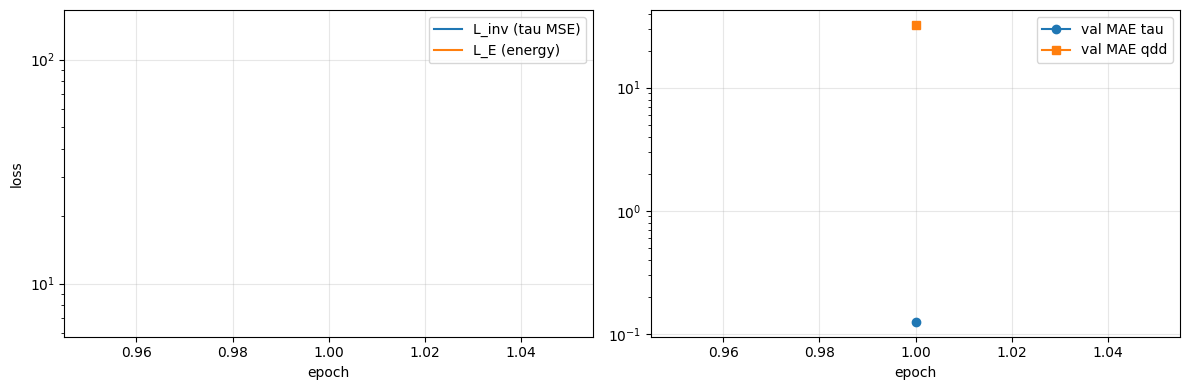

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].semilogy(hist['epoch'], hist['L_inv'], label='L_inv (tau MSE)')
axes[0].semilogy(hist['epoch'], hist['L_E'],   label='L_E (energy)')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss'); axes[0].legend(); axes[0].grid(True, alpha=.3)
if hist['val_epoch']:
    axes[1].semilogy(hist['val_epoch'], hist['val_mae_tau'], 'o-', label='val MAE tau')
    axes[1].semilogy(hist['val_epoch'], hist['val_mae_qdd'], 's-', label='val MAE qdd')
    axes[1].set_xlabel('epoch'); axes[1].legend(); axes[1].grid(True, alpha=.3)
plt.tight_layout(); plt.show()

## 4. Test-set performance

In [9]:
ck = torch.load(os.path.join(CKPT_DIR, 'delan_best91_sine_f1_1.pt'), map_location=device, weights_only=False)
model.load_state_dict(ck['model'])
print(f"Best checkpoint from epoch {ck['epoch']}")
for k, v in evaluate(model, val_set).items():
    print(f'  {k}: {v:.4e}')

Best checkpoint from epoch 590
  mae_tau: 4.9326e-03
  mae_qdd: 4.9050e+00
  rmse_tau: 1.3663e-02
  rmse_qdd: 1.3439e+01
